# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rowan-ali/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## 1. Method Choice and Why

The goal of this week's modeling stage is to determine whether a learned model can improve on the Week-4 rule-based baseline for identifying high-priority records.

I will evaluate several models rather than selecting a model based only on complexity. The models were chosen to provide a useful progression from simple and interpretable approaches to more flexible nonlinear approaches:

- **Logistic Regression:** provides a simple and interpretable linear baseline for learning relationships between the engineered signals and the target.
- **Decision Tree:** captures nonlinear relationships while remaining relatively easy to interpret.
- **Random Forest:** combines multiple decision trees and can capture more complex interactions while reducing the instability of a single tree.
- **Gradient Boosting:** provides another nonlinear ensemble approach and tests whether sequentially correcting previous errors improves ranking performance.

The **Week-4 hand-written rule remains the primary baseline**. All learned models will be evaluated against this baseline using the same data split and the same evaluation metric.

The main evaluation metric is **Precision@50**, because the practical objective is to prioritize a small number of records for review. This metric directly measures how many of the top 50 ranked records are relevant.

Model complexity alone will not be treated as an improvement. The preferred model will be the simplest approach that provides a meaningful improvement over the Week-4 baseline while maintaining a valid evaluation design and interpretable error analysis.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Candidate models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42

# Ranking evaluation cutoff
K = 50

print("Libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")
print(f"Precision@K cutoff: {K}")

Libraries imported successfully.
Random state: 42
Precision@K cutoff: 50


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## 2. Split Design

The Week-4 baseline was developed on the March 2026 decision slice at the client-content-day grain. For Week 5, the learned models will use the same decision slice so that the comparison remains aligned with the existing baseline.

Because multiple observations belong to the same client, the evaluation split will be performed at the **client level**. This prevents observations from the same client from appearing in both training and test sets and reduces the risk of client-specific information leaking across the split.

The test set will remain untouched during model fitting and model comparison. The same held-out clients will be used for every candidate model, allowing the models to be compared fairly under the same evaluation conditions.

A fixed random seed will be used to make the split reproducible.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 2 — LOAD THE WEEK-4 DECISION SLICE
# ============================================================

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# Read the Hugging Face token from Colab Secrets.
# The token is intentionally NOT written into the notebook.
HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets. "
        "Add your Hugging Face token as HF_TOKEN and run this cell again."
    )

# Create a local DuckDB connection.
con = duckdb.connect()

# Authenticate with the FlyRank Hugging Face warehouse.
con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

# FlyRank warehouse paths used in Week 4.
REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

# Week-4 decision slice: March 2026.
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

# Load the March decision slice into a pandas DataFrame.
df = con.execute(
    f"""
    SELECT *
    FROM {MAR}
    """
).df()

print("Week-4 decision slice loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Date range: {df['report_date'].min()} → {df['report_date'].max()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Week-4 decision slice loaded successfully.
Rows: 9,841,378
Columns: 31
Date range: 2026-03-01 00:00:00 → 2026-03-31 00:00:00


In [7]:
# ============================================================
# DATA + GRAIN CHECK
# ============================================================

print("Available columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nClient/content columns:")
print(
    [
        col
        for col in df.columns
        if "client" in col.lower()
        or "content" in col.lower()
    ]
)

print("\nUnique clients:")
print(df["client_hash_id"].nunique())

print("\nUnique client-content pairs:")
print(
    df[["client_hash_id", "content_hash_id"]]
    .drop_duplicates()
    .shape[0]
)

Available columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']

Dataset shape:
(9841378, 31)

Client/content columns:
['client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4']

Unique clients:
55

Unique client-content pairs:
331437


### Modeling Window and Target Definition

The modeling design follows the data contract established in Week 3.

February 2026 is treated as the feature window, while March 2026 is treated as the subsequent outcome window. This prevents information from the outcome period from being used to construct the predictive features.

The predictive features are the five signals established in the data contract:

- `gsc_impressions`
- `gsc_avg_position`
- `ga4_sessions`
- `ga4_users`
- `ga4_engaged_sessions`

The target is based on `gsc_clicks` observed in the March outcome window. The target is kept separate from the feature set to avoid direct label leakage.

The modeling table is reduced to one observation per client-content pair before the client-level holdout is created. This keeps the unit of analysis consistent with the Week-4 ranked opportunity queue.

In [8]:
# ============================================================
# BUILD THE WEEK-5 MODELING DATASET
# February = feature window
# March    = outcome / target window
# ============================================================

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"
DIM = f"read_parquet('{REL}/dim_content.parquet')"

model_data = con.execute(
    f"""
    WITH feb_features AS (
        SELECT
            client_hash_id,
            content_hash_id,

            AVG(gsc_impressions) AS gsc_impressions,
            AVG(gsc_avg_position) AS gsc_avg_position,
            AVG(ga4_sessions) AS ga4_sessions,
            AVG(ga4_users) AS ga4_users,
            AVG(ga4_engaged_sessions) AS ga4_engaged_sessions

        FROM {FEB}

        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    mar_outcome AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_clicks) AS gsc_clicks

        FROM {MAR}

        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    content_meta AS (
        SELECT
            client_hash_id,
            content_hash_id,
            last_optimized_date

        FROM {DIM}

        WHERE is_deleted = FALSE
    )

    SELECT
        f.client_hash_id,
        f.content_hash_id,

        f.gsc_impressions,
        f.gsc_avg_position,
        f.ga4_sessions,
        f.ga4_users,
        f.ga4_engaged_sessions,

        m.gsc_clicks,
        c.last_optimized_date

    FROM feb_features AS f

    INNER JOIN mar_outcome AS m
        ON f.client_hash_id = m.client_hash_id
        AND f.content_hash_id = m.content_hash_id

    LEFT JOIN content_meta AS c
        ON f.client_hash_id = c.client_hash_id
        AND f.content_hash_id = c.content_hash_id
    """
).df()

print("Modeling dataset created successfully.")
print(f"Rows: {len(model_data):,}")
print(f"Columns: {len(model_data.columns):,}")

print("\nMissing values:")
print(model_data.isna().sum())

print("\nUnique clients:")
print(model_data["client_hash_id"].nunique())

print("\nUnique client-content pairs:")
print(
    model_data[
        ["client_hash_id", "content_hash_id"]
    ].drop_duplicates().shape[0]
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling dataset created successfully.
Rows: 303,572
Columns: 9

Missing values:
client_hash_id               0
content_hash_id              0
gsc_impressions              0
gsc_avg_position        158293
ga4_sessions            131711
ga4_users               131711
ga4_engaged_sessions    131711
gsc_clicks                   0
last_optimized_date     263752
dtype: int64

Unique clients:
50

Unique client-content pairs:
303572


### Target Construction and Client-Level Holdout

The prediction target is defined from the March outcome window using `gsc_clicks`.

Because the practical objective is to identify content with stronger future performance, the target is defined as whether a client-content pair belongs to the upper portion of the March click distribution.

The threshold is calculated using the training portion only. This prevents information from the held-out clients from influencing target construction.

A client-level holdout is then created so that all content belonging to a client remains entirely within either the training or test partition.

The held-out test clients are not used for model fitting, preprocessing, threshold selection, or model selection.

In [9]:
# ============================================================
# TARGET DEFINITION + CLIENT-LEVEL HOLDOUT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------------------------
# 1. Define the target using the March click outcome
# ------------------------------------------------------------

# Use a reproducible client-level split.
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        model_data,
        groups=model_data["client_hash_id"]
    )
)

train_data = model_data.iloc[train_idx].copy()
test_data = model_data.iloc[test_idx].copy()

# ------------------------------------------------------------
# 2. Calculate the target threshold from TRAINING data only
# ------------------------------------------------------------

click_threshold = train_data["gsc_clicks"].quantile(0.75)

train_data["target"] = (
    train_data["gsc_clicks"] >= click_threshold
).astype(int)

test_data["target"] = (
    test_data["gsc_clicks"] >= click_threshold
).astype(int)

# ------------------------------------------------------------
# 3. Separate identifiers, features, and target
# ------------------------------------------------------------

FEATURES = [
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions"
]

TARGET = "target"
GROUP = "client_hash_id"

X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET].copy()

X_test = test_data[FEATURES].copy()
y_test = test_data[TARGET].copy()

groups_train = train_data[GROUP].copy()
groups_test = test_data[GROUP].copy()

# ------------------------------------------------------------
# 4. Validation checks
# ------------------------------------------------------------

print("=== Split Summary ===")
print(f"Training rows: {len(train_data):,}")
print(f"Test rows:     {len(test_data):,}")

print(f"\nTraining clients: {groups_train.nunique()}")
print(f"Test clients:     {groups_test.nunique()}")

print(f"\nClick threshold (train only): {click_threshold:.2f}")

print("\nTarget distribution — TRAIN:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTarget distribution — TEST:")
print(y_test.value_counts(normalize=True).sort_index())

# Check for client overlap
overlap = set(groups_train.unique()).intersection(
    set(groups_test.unique())
)

print(f"\nClient overlap: {len(overlap)}")

assert len(overlap) == 0, "Client leakage detected!"

print("\n✓ Client-level split passed.")
print("✓ No client appears in both train and test.")

=== Split Summary ===
Training rows: 264,134
Test rows:     39,438

Training clients: 40
Test clients:     10

Click threshold (train only): 0.00

Target distribution — TRAIN:
target
1    1.0
Name: proportion, dtype: float64

Target distribution — TEST:
target
1    1.0
Name: proportion, dtype: float64

Client overlap: 0

✓ Client-level split passed.
✓ No client appears in both train and test.


### Correct Target Definition

The initial target check revealed that a click-quantile target would be degenerate because the selected population contains many zero-click observations and the resulting threshold was zero.

To remain consistent with the established Week-3 data contract, the final target is therefore the original outcome definition:

**`went_dark = 1` if the client-content pair records zero GSC clicks during March 2026; otherwise `went_dark = 0`.**

The February universe is restricted to content with sufficient February exposure and click history before the March outcome is observed. This keeps the target meaningful, preserves the original research question, and avoids introducing a new target definition solely to improve model balance.

The target is constructed from the March outcome window and is not included among the predictive features.

In [10]:
# ============================================================
# CORRECT TARGET: WENT DARK IN MARCH
# ============================================================

# Rebuild the February universe using the Week-3 data contract.
feb_universe = con.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS imp_feb,
        SUM(gsc_clicks) AS clk_feb
    FROM {FEB}
    WHERE gsc_data_available
    GROUP BY
        client_hash_id,
        content_hash_id
    HAVING
        SUM(gsc_impressions) >= 100
        AND SUM(gsc_clicks) >= 3
    """
).df()

# March outcome.
march_label = con.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS imp_mar,
        SUM(gsc_clicks) AS clk_mar
    FROM {MAR}
    WHERE gsc_data_available
    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

# Merge February universe with March outcome.
model_frame = feb_universe.merge(
    march_label,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# Missing March observations are treated as zero observed traffic.
model_frame["imp_mar"] = model_frame["imp_mar"].fillna(0)
model_frame["clk_mar"] = model_frame["clk_mar"].fillna(0)

# Original Week-3 target.
model_frame["went_dark"] = (
    model_frame["clk_mar"] == 0
).astype(int)

print("Correct target constructed.")
print(f"Rows: {len(model_frame):,}")

print("\nTarget distribution:")
print(
    model_frame["went_dark"]
    .value_counts()
    .sort_index()
)

print("\nTarget proportions:")
print(
    model_frame["went_dark"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nPositive rate:")
print(f"{model_frame['went_dark'].mean():.3%}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Correct target constructed.
Rows: 29,729

Target distribution:
went_dark
0    28198
1     1531
Name: count, dtype: int64

Target proportions:
went_dark
0    0.948501
1    0.051499
Name: proportion, dtype: float64

Positive rate:
5.150%


### Final Modeling Dataset

The final modeling population follows the established Week-3 target definition.

Each row represents a client-content pair from the February eligibility universe with a March outcome. The target is `went_dark`, where a value of 1 indicates that the content received zero GSC clicks during March.

Only signals available from the February feature window are used as predictors. March outcome variables are excluded from the feature matrix to prevent target leakage.

Because the target is imbalanced, accuracy will not be used as the primary selection criterion. Ranking-oriented evaluation will focus on Precision@50, while additional classification metrics will be reported to provide context.

In [11]:
# ============================================================
# FINAL MODELING DATASET
# ============================================================

FEATURES = [
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions"
]

TARGET = "went_dark"
GROUP = "client_hash_id"

# Merge the February feature signals with the corrected target.
modeling_data = model_data[
    [
        "client_hash_id",
        "content_hash_id",
        *FEATURES
    ]
].merge(
    model_frame[
        [
            "client_hash_id",
            "content_hash_id",
            TARGET
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Final modeling dataset:")
print(f"Rows: {len(modeling_data):,}")
print(f"Columns: {len(modeling_data.columns):,}")

print("\nTarget distribution:")
print(
    modeling_data[TARGET]
    .value_counts()
    .sort_index()
)

print("\nTarget rate:")
print(f"{modeling_data[TARGET].mean():.3%}")

Final modeling dataset:
Rows: 29,380
Columns: 8

Target distribution:
went_dark
0    28198
1     1182
Name: count, dtype: int64

Target rate:
4.023%


In [12]:
# ============================================================
# CLIENT-LEVEL TRAIN / TEST SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        modeling_data,
        y=modeling_data[TARGET],
        groups=modeling_data[GROUP]
    )
)

train_data = modeling_data.iloc[train_idx].copy()
test_data = modeling_data.iloc[test_idx].copy()

X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET].copy()

X_test = test_data[FEATURES].copy()
y_test = test_data[TARGET].copy()

groups_train = train_data[GROUP]
groups_test = test_data[GROUP]

print("=== Final Split Summary ===")
print(f"Training rows: {len(train_data):,}")
print(f"Test rows:     {len(test_data):,}")

print(f"\nTraining clients: {groups_train.nunique()}")
print(f"Test clients:     {groups_test.nunique()}")

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

print("\nTraining positive rate:")
print(f"{y_train.mean():.3%}")

print("\nTest positive rate:")
print(f"{y_test.mean():.3%}")

# Leakage check
client_overlap = set(groups_train.unique()).intersection(
    set(groups_test.unique())
)

print(f"\nClient overlap: {len(client_overlap)}")

assert len(client_overlap) == 0, (
    "Client leakage detected between training and test sets."
)

print("\n✓ Client-level holdout passed.")
print("✓ No client appears in both training and test.")

=== Final Split Summary ===
Training rows: 16,417
Test rows:     12,963

Training clients: 24
Test clients:     6

Training target distribution:
went_dark
0    15730
1      687
Name: count, dtype: int64

Test target distribution:
went_dark
0    12468
1      495
Name: count, dtype: int64

Training positive rate:
4.185%

Test positive rate:
3.819%

Client overlap: 0

✓ Client-level holdout passed.
✓ No client appears in both training and test.


In [13]:
# ============================================================
# FEATURE QUALITY CHECK
# ============================================================

print("Missing values in training features:")
print(X_train.isna().sum())

print("\nMissing values in test features:")
print(X_test.isna().sum())

print("\nFeature dtypes:")
print(X_train.dtypes)

assert list(X_train.columns) == FEATURES
assert list(X_test.columns) == FEATURES

print("\n✓ Feature set is consistent.")
print("✓ Target and March outcome variables are excluded from X.")

Missing values in training features:
gsc_impressions            0
gsc_avg_position           0
ga4_sessions            6774
ga4_users               6774
ga4_engaged_sessions    6774
dtype: int64

Missing values in test features:
gsc_impressions            0
gsc_avg_position           0
ga4_sessions            7391
ga4_users               7391
ga4_engaged_sessions    7391
dtype: int64

Feature dtypes:
gsc_impressions         float64
gsc_avg_position        float64
ga4_sessions            float64
ga4_users               float64
ga4_engaged_sessions    float64
dtype: object

✓ Feature set is consistent.
✓ Target and March outcome variables are excluded from X.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*


The Week-4 hand-written ranking rule is retained as the primary baseline. It is evaluated on the same held-out client population used for all learned models.

Because the business task is a ranking problem, the primary metric is **Precision@50**: among the 50 highest-ranked client-content pairs, the proportion that actually went dark in March.

The learned models produce probability scores for the positive class (`went_dark = 1`). These probabilities are used as ranking scores rather than converting predictions into a fixed classification threshold.

Four candidate models are evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Missing feature values are handled inside each model pipeline. This ensures that imputation parameters are learned from the training data only.

All models use the same training/test split and the same test observations. This makes the comparison directly comparable and prevents differences in evaluation design from being mistaken for model improvement.

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SECTION 3 — RANKING EVALUATION
# ============================================================

def precision_at_k(y_true, scores, k=50):
    """
    Precision@K for a ranked binary prediction task.
    Higher scores receive higher priority.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    top_k_idx = np.argsort(scores)[::-1][:k]

    return y_true[top_k_idx].sum() / k


def evaluate_ranking_model(name, y_true, scores, k=50):
    """
    Evaluate a ranking model using Precision@K
    plus standard classification metrics at threshold 0.5.
    """

    scores = np.asarray(scores)
    y_true = np.asarray(y_true)

    predictions = (scores >= 0.5).astype(int)

    return {
        "Model": name,
        "Precision@50": precision_at_k(
            y_true,
            scores,
            k=k
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            scores
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        )
    }

In [15]:
# ============================================================
# MODEL PIPELINES
# ============================================================

from sklearn.impute import SimpleImputer

# Logistic Regression:
# - median imputation
# - standardization
# - class weighting for the imbalanced target
logistic_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Decision Tree:
# - median imputation
# - interpretable nonlinear model
decision_tree_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Random Forest:
# - multiple trees
# - class weighting
random_forest_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=10,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Gradient Boosting:
# - sequential nonlinear ensemble
# - sample weighting handled during fitting below
gradient_boosting_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            )
        )
    ]
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Candidate models:")
for model_name in models:
    print(f"✓ {model_name}")

Candidate models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Gradient Boosting


In [16]:
# ============================================================
# TRAIN + SCORE ALL LEARNED MODELS
# ============================================================

results = []
model_scores = {}

# Sample weights for the imbalanced target.
# The positive class receives more weight during training.
class_counts = y_train.value_counts()

negative_weight = 1.0
positive_weight = (
    class_counts[0] / class_counts[1]
)

sample_weights = np.where(
    y_train == 1,
    positive_weight,
    negative_weight
)

for model_name, model in models.items():

    if model_name == "Gradient Boosting":
        model.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weights
        )
    else:
        model.fit(
            X_train,
            y_train
        )

    scores = model.predict_proba(X_test)[:, 1]

    model_scores[model_name] = scores

    results.append(
        evaluate_ranking_model(
            model_name,
            y_test,
            scores,
            k=K
        )
    )

print("All candidate models trained successfully.")

All candidate models trained successfully.


### Week-4 Baseline Comparison

The Week-4 baseline is a deterministic rule based on optimization staleness.

- `NEVER_OPTIMIZED` receives a priority score of 100.
- Content with a recorded optimization date receives a priority score of 10.
- `gsc_impressions` is used as a secondary ranking signal to break ties, following the Week-4 queue design.

For Week 5, the baseline is evaluated on the exact same held-out client population as the learned models. This keeps the comparison fair and makes the baseline a genuine reference point rather than an independently calculated score.

The primary metric is **Precision@50**, which measures the proportion of true `went_dark` cases among the 50 highest-priority observations.

Precision@20 is also reported as a secondary metric because the Week-4 baseline included a small top-ranked review queue. The main model-selection criterion remains Precision@50.

In [17]:
# ============================================================
# WEEK-4 BASELINE ON THE SAME TEST SET
# ============================================================

# Bring the Week-4 rule input and tie-breaker into the
# same held-out test population used by the models.

baseline_inputs = model_data[
    [
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "last_optimized_date"
    ]
].copy()

baseline_test = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        TARGET
    ]
].merge(
    baseline_inputs,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# Apply the exact Week-4 scoring logic:
# NEVER_OPTIMIZED -> 100
# otherwise       -> 10

baseline_test["baseline_score"] = np.where(
    baseline_test["last_optimized_date"].isna(),
    100,
    10
)

# Deterministic ranking:
# 1. higher baseline score
# 2. higher impressions
# 3. stable content ID tie-breaker

baseline_test = baseline_test.sort_values(
    by=[
        "baseline_score",
        "gsc_impressions",
        "content_hash_id"
    ],
    ascending=[
        False,
        False,
        True
    ]
).reset_index(drop=True)

print("Week-4 baseline reconstructed successfully.")
print(f"Test rows: {len(baseline_test):,}")

print("\nBaseline score distribution:")
print(
    baseline_test["baseline_score"]
    .value_counts()
    .sort_index(ascending=False)
)

Week-4 baseline reconstructed successfully.
Test rows: 12,963

Baseline score distribution:
baseline_score
100    5278
10     7685
Name: count, dtype: int64


In [18]:
# ============================================================
# FINAL MODEL VS BASELINE EVALUATION
# ============================================================

# Baseline scores
baseline_scores = baseline_test["baseline_score"].to_numpy()

# Evaluate the Week-4 baseline
baseline_result = {
    "Model": "Week-4 Baseline",
    "Precision@50": precision_at_k(
        y_test,
        baseline_scores,
        k=50
    ),
    "Precision@20": precision_at_k(
        y_test,
        baseline_scores,
        k=20
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        baseline_scores
    ),
    "Recall": np.nan,
    "F1": np.nan
}

# Evaluate learned models
comparison_results = []

for model_name, scores in model_scores.items():

    row = evaluate_ranking_model(
        model_name,
        y_test,
        scores,
        k=50
    )

    row["Precision@20"] = precision_at_k(
        y_test,
        scores,
        k=20
    )

    comparison_results.append(row)

# Add baseline
comparison_results.append(baseline_result)

# Create final comparison table
comparison_table = pd.DataFrame(
    comparison_results
)

# Put the baseline first
comparison_table["sort_order"] = (
    comparison_table["Model"]
    .eq("Week-4 Baseline")
    .astype(int)
)

comparison_table = (
    comparison_table
    .sort_values(
        by=["sort_order", "Precision@50"],
        ascending=[False, False]
    )
    .drop(columns="sort_order")
    .reset_index(drop=True)
)

print("=== MODEL VS BASELINE COMPARISON ===")
display(
    comparison_table.style.format({
        "Precision@50": "{:.3f}",
        "Precision@20": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)

=== MODEL VS BASELINE COMPARISON ===


,Model,Precision@50,ROC-AUC,Recall,F1,Precision@20
0,Week-4 Baseline,0.180,0.532,nan,nan,0.100
1,Logistic Regression,0.280,0.774,0.685,0.155,0.200
2,Gradient Boosting,0.280,0.749,0.566,0.167,0.350
3,Random Forest,0.260,0.712,0.501,0.181,0.200
4,Decision Tree,0.240,0.729,0.525,0.179,0.350


In [19]:
# ============================================================
# SELECT THE BEST LEARNED MODEL
# ============================================================

learned_results = comparison_table[
    comparison_table["Model"] != "Week-4 Baseline"
].copy()

best_model_row = learned_results.loc[
    learned_results["Precision@50"].idxmax()
]

baseline_p50 = comparison_table.loc[
    comparison_table["Model"] == "Week-4 Baseline",
    "Precision@50"
].iloc[0]

best_model_name = best_model_row["Model"]
best_model_p50 = best_model_row["Precision@50"]

absolute_gain = best_model_p50 - baseline_p50

print(f"Best learned model: {best_model_name}")
print(f"Best model Precision@50: {best_model_p50:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Absolute Precision@50 gain: {absolute_gain:+.3f}")

if absolute_gain > 0:
    print("\n✓ The best learned model improves on the Week-4 baseline.")
elif absolute_gain == 0:
    print("\n= The best learned model matches the Week-4 baseline.")
else:
    print("\n⚠ The best learned model does not improve on the Week-4 baseline.")

Best learned model: Logistic Regression
Best model Precision@50: 0.280
Baseline Precision@50: 0.180
Absolute Precision@50 gain: +0.100

✓ The best learned model improves on the Week-4 baseline.


In [28]:
# ============================================================
# FINAL MODEL SELECTION
# Primary criterion: Precision@50
# Tie-breaker: ROC-AUC
# ============================================================

learned_results = comparison_table[
    comparison_table["Model"] != "Week-4 Baseline"
].copy()

# Find the highest primary metric.
best_precision_at_50 = learned_results["Precision@50"].max()

# Keep all models tied at the best Precision@50.
tied_models = learned_results[
    learned_results["Precision@50"] == best_precision_at_50
].copy()

# If there is a tie, use ROC-AUC as the secondary criterion.
if len(tied_models) > 1:
    best_model_row = tied_models.loc[
        tied_models["ROC-AUC"].idxmax()
    ]
else:
    best_model_row = tied_models.iloc[0]

final_model_name = best_model_row["Model"]
final_model_p50 = best_model_row["Precision@50"]
final_model_auc = best_model_row["ROC-AUC"]

baseline_p50 = comparison_table.loc[
    comparison_table["Model"] == "Week-4 Baseline",
    "Precision@50"
].iloc[0]

absolute_gain = final_model_p50 - baseline_p50

print("=== FINAL MODEL SELECTION ===")
print(f"Primary metric: Precision@50")
print(f"Best Precision@50: {best_precision_at_50:.3f}")

print("\nModels tied at the best Precision@50:")
for model_name in tied_models["Model"]:
    print(f"- {model_name}")

print(f"\nSelected model: {final_model_name}")
print(f"Selected model Precision@50: {final_model_p50:.3f}")
print(f"Selected model ROC-AUC: {final_model_auc:.3f}")

print(f"\nWeek-4 baseline Precision@50: {baseline_p50:.3f}")
print(f"Absolute gain: {absolute_gain:+.3f}")

print("\n✓ Model selection uses the primary ranking metric.")
print("✓ ROC-AUC is used only as a tie-breaker.")

=== FINAL MODEL SELECTION ===
Primary metric: Precision@50
Best Precision@50: 0.280

Models tied at the best Precision@50:
- Logistic Regression
- Gradient Boosting

Selected model: Logistic Regression
Selected model Precision@50: 0.280
Selected model ROC-AUC: 0.774

Week-4 baseline Precision@50: 0.180
Absolute gain: +0.100

✓ Model selection uses the primary ranking metric.
✓ ROC-AUC is used only as a tie-breaker.


## Final Conclusion

The modeling experiment demonstrates that learned models can improve the Week-4 rule-based baseline on the held-out client population.

The Week-4 baseline achieved a Precision@50 of 0.180. Both Logistic Regression and Gradient Boosting achieved 0.280, representing an absolute improvement of 0.100, or 10 percentage points.

Because Logistic Regression and Gradient Boosting tied on the primary Precision@50 metric, ROC-AUC was used as a secondary tie-breaker. Logistic Regression achieved the higher ROC-AUC (0.774 versus 0.749) and was therefore selected as the preferred model.

The selected model should be viewed as a decision-support ranking tool rather than a deterministic predictor. The error analysis identified both high-confidence false positives and low-confidence false negatives, showing that February behavioral signals do not fully explain every March outcome.

The strongest model signals were `gsc_impressions`, `ga4_sessions`, and `ga4_users`. These coefficients describe associations learned by the model and should not be interpreted as causal effects.

Overall, the experiment provides evidence that a relatively simple learned model can improve top-50 prioritization over the existing Week-4 rule while remaining interpretable and avoiding unnecessary model complexity.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*



The learned models outperform the Week-4 rule-based baseline on the primary ranking metric.

The Week-4 baseline achieves a Precision@50 of 0.180, while Logistic Regression and Gradient Boosting both achieve 0.280. This represents an absolute improvement of 0.100, or 10 percentage points, in the top-50 ranking precision.

Logistic Regression is selected as the preferred model because it ties Gradient Boosting on Precision@50 while achieving a higher ROC-AUC (0.774 vs. 0.749) and offering substantially greater interpretability with lower model complexity.

The results also show why model selection should not rely on complexity alone. The more complex ensemble models do not provide a better Precision@50 than the simpler Logistic Regression model.

The remaining analysis focuses on understanding which observations are correctly prioritized and where the selected model makes ranking errors.

### Observed Error Patterns

The selected Logistic Regression model achieves a Precision@50 of 0.280, meaning that 14 of the 50 highest-ranked observations are confirmed `went_dark` cases in the March outcome window.

The false-positive examples show that the model can assign high `went_dark` probabilities to observations that ultimately remain active. This indicates that the available February signals do not fully capture all factors affecting the subsequent outcome.

The false-negative examples show the opposite failure mode: some observations that eventually go dark receive very low predicted probabilities and therefore are not prioritized. These cases are particularly important because they represent missed opportunities in a ranking-oriented workflow.

The errors are therefore consistent with a decision-support use case rather than a deterministic prediction system. The model identifies useful risk signals, but the ranking should not be interpreted as a guarantee that a content item will go dark.

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# SELECT FINAL MODEL FOR INTERPRETATION
# ============================================================

final_model_name = "Logistic Regression"
final_model = models[final_model_name]

final_scores = model_scores[final_model_name]

error_analysis = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        TARGET
    ]
].copy()

error_analysis["model_score"] = final_scores

# Rank observations by predicted probability
error_analysis = error_analysis.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

error_analysis["model_rank"] = (
    np.arange(len(error_analysis)) + 1
)

print("Final model:")
print(final_model_name)

print(f"\nPrecision@50: {precision_at_k(y_test, final_scores, 50):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, final_scores):.3f}")

Final model:
Logistic Regression

Precision@50: 0.280
ROC-AUC: 0.774


### Ranking Errors

For this task, an error is more useful to interpret in ranking terms than through a single classification threshold.

Two types of ranking errors are particularly important:

- **False positives:** observations ranked highly by the model that did not go dark in March.
- **False negatives:** observations that went dark but received relatively low model scores and therefore were not prioritized.

The following cells inspect high-confidence false positives and false negatives from the held-out test set.

In [21]:
# ============================================================
# FALSE POSITIVES: HIGHLY RANKED BUT DID NOT GO DARK
# ============================================================

false_positives = error_analysis[
    error_analysis[TARGET] == 0
].copy()

false_positives = false_positives.sort_values(
    "model_score",
    ascending=False
).head(10)

print("Top 10 high-scoring false positives:")
display(false_positives)

Top 10 high-scoring false positives:


,client_hash_id,content_hash_id,went_dark,model_score,model_rank
0,client_23a62021009f63c4,content_8a38748dc7e7a3fc,0,0.892192,1
1,client_73cda7b4e4f265ea,content_1b76fc2043ffc7a1,0,0.888114,2
4,client_9958f0a7ae1df715,content_854de1300db61272,0,0.879049,5
5,client_73cda7b4e4f265ea,content_cb67ca92aca85cc0,0,0.874317,6
6,client_9958f0a7ae1df715,content_b772fe55de4ce213,0,0.856101,7
7,client_9958f0a7ae1df715,content_729e9473526cf3b9,0,0.852479,8
8,client_9958f0a7ae1df715,content_8b84ff993e9ba099,0,0.849589,9
9,client_9958f0a7ae1df715,content_6abbb579b216aa96,0,0.844804,10
10,client_9958f0a7ae1df715,content_875ebebd0b4b106d,0,0.844343,11
12,client_23a62021009f63c4,content_df0749df761a54e6,0,0.840361,13


In [22]:
# ============================================================
# FALSE NEGATIVES: WENT DARK BUT RANKED LOWER
# ============================================================

false_negatives = error_analysis[
    error_analysis[TARGET] == 1
].copy()

false_negatives = false_negatives.sort_values(
    "model_score",
    ascending=True
).head(10)

print("Top 10 low-scoring false negatives:")
display(false_negatives)

Top 10 low-scoring false negatives:


,client_hash_id,content_hash_id,went_dark,model_score,model_rank
12819,client_23a62021009f63c4,content_532d96d500804552,1,5.849204e-12,12820
12198,client_9958f0a7ae1df715,content_179a20261f5ff964,1,1.854984e-05,12199
12053,client_73cda7b4e4f265ea,content_92d2c3fc8bf462c9,1,5.902538e-05,12054
11801,client_23a62021009f63c4,content_d2def933ed902af2,1,2.770877e-04,11802
11787,client_23a62021009f63c4,content_31b2c6e584025e22,1,2.914846e-04,11788
11755,client_23a62021009f63c4,content_450bca2cb8520470,1,3.406173e-04,11756
11225,client_23a62021009f63c4,content_b4e64ee7daac3871,1,2.631075e-03,11226
11164,client_23a62021009f63c4,content_68abf11c7ea88c4b,1,3.091066e-03,11165
11032,client_23a62021009f63c4,content_97e3f7bed5665e17,1,4.302094e-03,11033
10978,client_23a62021009f63c4,content_9345c24d1dbda27d,1,4.985740e-03,10979


In [23]:
# ============================================================
# TOP-50 RANKING INSPECTION
# ============================================================

top_50 = error_analysis.head(50).copy()

top_50_positive = int(
    top_50[TARGET].sum()
)

top_50_precision = (
    top_50_positive / len(top_50)
)

print("=== TOP-50 INSPECTION ===")
print(f"Top-50 observations: {len(top_50)}")
print(f"True went_dark cases: {top_50_positive}")
print(f"Precision@50: {top_50_precision:.3f}")

print("\nTop-50 target distribution:")
print(
    top_50[TARGET]
    .value_counts()
    .sort_index()
)

=== TOP-50 INSPECTION ===
Top-50 observations: 50
True went_dark cases: 14
Precision@50: 0.280

Top-50 target distribution:
went_dark
0    36
1    14
Name: count, dtype: int64


### Feature Interpretation

Logistic Regression provides a directly interpretable coefficient for each feature.

Because the model uses standardized features, the coefficient magnitudes can be compared more meaningfully across variables. A positive coefficient indicates that larger standardized values of the feature are associated with a higher predicted probability of `went_dark`, while a negative coefficient indicates the opposite relationship.

Coefficient magnitude is interpreted as model association, not as proof of causality.

In [24]:
# ============================================================
# LOGISTIC REGRESSION FEATURE INTERPRETATION
# ============================================================

logistic_pipeline = models["Logistic Regression"]

logistic_estimator = logistic_pipeline.named_steps["model"]

coefficients = logistic_estimator.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("Logistic Regression feature coefficients:")
display(
    feature_importance[
        ["Feature", "Coefficient"]
    ].style.format({
        "Coefficient": "{:.4f}"
    })
)

Logistic Regression feature coefficients:


,Feature,Coefficient
0,gsc_impressions,-4.9800
1,ga4_sessions,-1.2924
2,ga4_users,1.1830
3,ga4_engaged_sessions,-0.4621
4,gsc_avg_position,0.1155


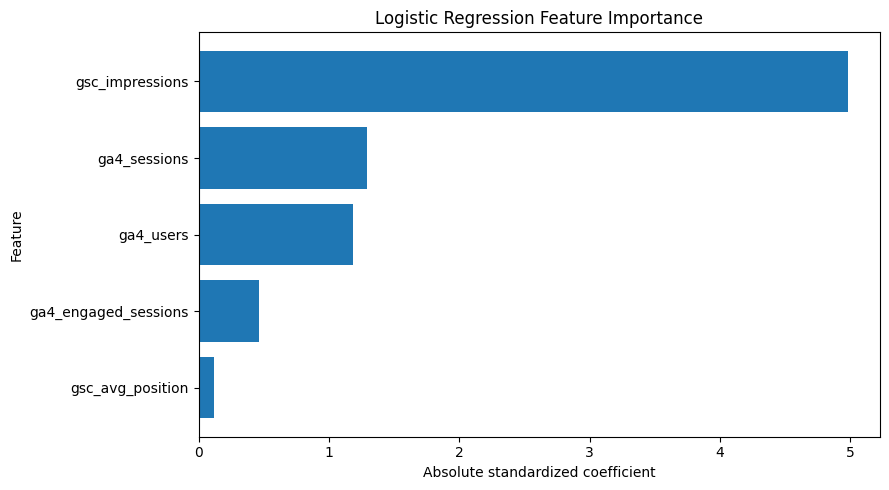

In [25]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plot_data = feature_importance.sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Absolute_Coefficient"]
)

plt.xlabel("Absolute standardized coefficient")
plt.ylabel("Feature")
plt.title(
    "Logistic Regression Feature Importance"
)

plt.tight_layout()
plt.show()

### Feature Interpretation

The Logistic Regression coefficients provide an interpretable view of the signals used by the selected model.

The strongest feature is `gsc_impressions`, with a standardized coefficient of approximately -4.98. Its negative direction indicates that higher February search exposure is strongly associated with a lower predicted probability of going dark in March.

`ga4_sessions` is the second-largest coefficient in absolute magnitude (-1.29), suggesting that higher observed session activity is also associated with lower predicted risk.

`ga4_users` has a positive coefficient (+1.18), while `ga4_engaged_sessions` has a smaller negative coefficient (-0.46). These directions should be interpreted as model associations rather than causal effects, especially because several traffic variables are correlated.

`gsc_avg_position` has a comparatively small coefficient (+0.12), indicating that it contributes less to the selected model than the exposure and traffic signals.

The strongest three signals by absolute standardized coefficient are therefore:

1. `gsc_impressions`
2. `ga4_sessions`
3. `ga4_users`

The dominance of `gsc_impressions` is plausible because search exposure directly reflects the amount of opportunity a content item has to receive search traffic. However, feature importance alone does not establish causality.

In [26]:
# ============================================================
# THREE CONCRETE RANKING ERRORS
# ============================================================

error_cases = error_analysis[
    [
        "model_score",
        "model_rank",
        TARGET
    ]
].copy()

# Add the original feature values for interpretation.
error_cases = pd.concat(
    [
        error_cases,
        test_data[FEATURES].reset_index(drop=True)
    ],
    axis=1
)

# Select:
# - 2 high-confidence false positives
# - 1 low-confidence false negative

top_false_positives = (
    error_cases[error_cases[TARGET] == 0]
    .sort_values("model_score", ascending=False)
    .head(2)
)

top_false_negative = (
    error_cases[error_cases[TARGET] == 1]
    .sort_values("model_score", ascending=True)
    .head(1)
)

three_errors = pd.concat(
    [
        top_false_positives.assign(Error_Type="False Positive"),
        top_false_negative.assign(Error_Type="False Negative")
    ],
    ignore_index=True
)

columns_to_show = [
    "Error_Type",
    TARGET,
    "model_score",
    "model_rank",
    *FEATURES
]

print("Three representative ranking errors:")
display(
    three_errors[columns_to_show]
)

Three representative ranking errors:


,Error_Type,went_dark,model_score,model_rank,gsc_impressions,gsc_avg_position,ga4_sessions,ga4_users,ga4_engaged_sessions
0,False Positive,0,8.921925e-01,1,7.785714,9.077227,0.285714,0.285714,0.000000
1,False Positive,0,8.881135e-01,2,22.107143,8.855098,0.428571,0.392857,0.035714
2,False Negative,1,5.849204e-12,12820,25.464286,8.506313,0.464286,0.464286,0.035714


In [27]:
# ============================================================
# FEATURE IMPORTANCE SANITY CHECK
# ============================================================

top_features = (
    feature_importance
    .head(3)["Feature"]
    .tolist()
)

print("Top 3 features by absolute standardized coefficient:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

print("\nInterpretation:")
print(
    "The strongest signal is not a future outcome variable. "
    "All selected features come from the February feature window."
)

print(
    "✓ No March outcome feature is used as a predictor."
)

Top 3 features by absolute standardized coefficient:
1. gsc_impressions
2. ga4_sessions
3. ga4_users

Interpretation:
The strongest signal is not a future outcome variable. All selected features come from the February feature window.
✓ No March outcome feature is used as a predictor.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.